Libraries loaded successfully.
Male   test set : 1,627
Female test set : 2,405
=== Table 1: Integrated Performance — XGBoost (Male vs Female) ===
Cohort  N (test) Diabetic rate  Accuracy  Precision  Recall     F1    AUC  PR-AUC  Brier Score  Threshold
  Male      1627         30.0%    0.7683     0.6130  0.6168 0.6149 0.8363  0.6204       0.1665       0.67
Female      2405         20.0%    0.8341     0.6319  0.4042 0.4930 0.8765  0.5809       0.1312       0.70

Saved: outputs/table1_integrated_performance.csv


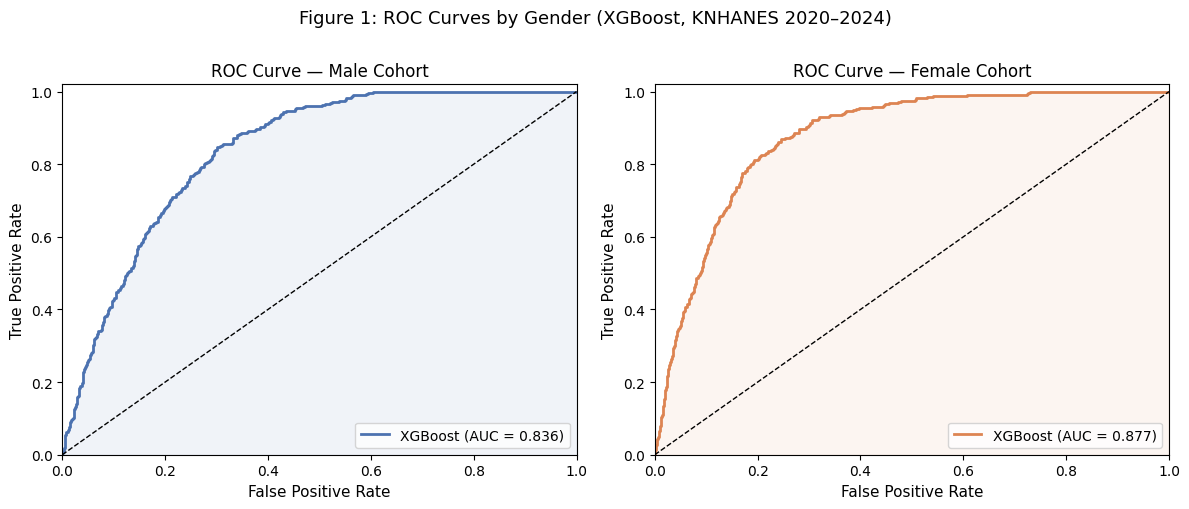

Saved: outputs/fig1_roc_male_female.png


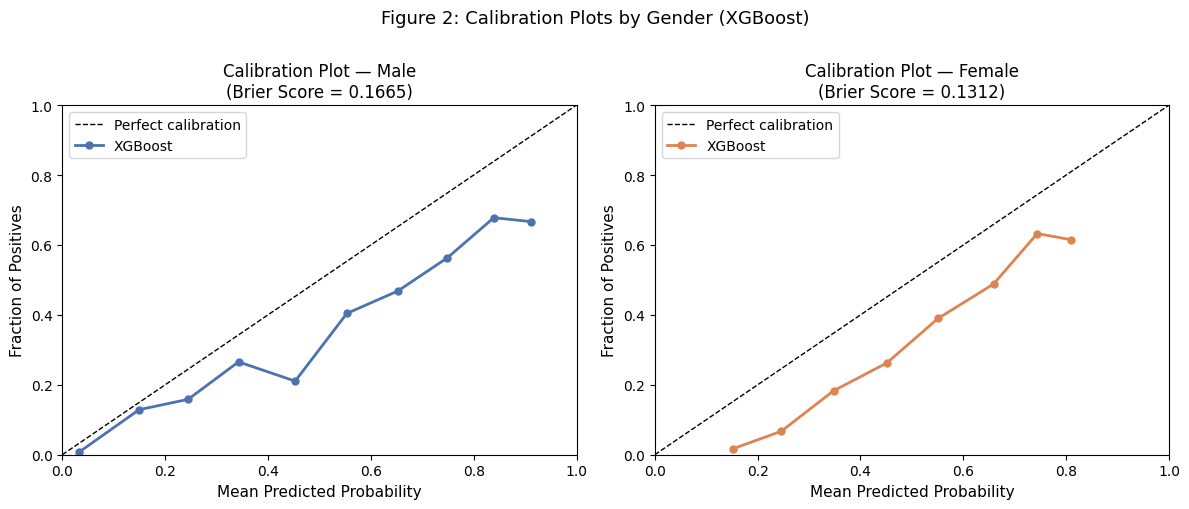

Saved: outputs/fig2_calibration_male_female.png


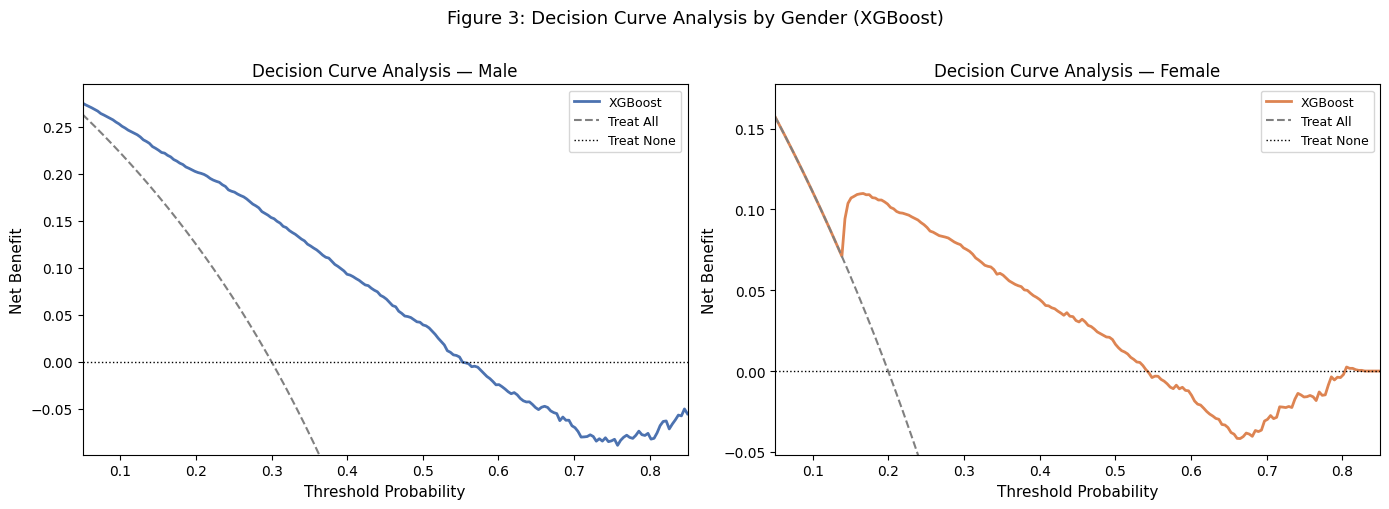

Saved: outputs/fig3_dca_male_female.png
Gender-Stratified Model Validity Test
Single model (sex included) vs Separated models

[Single Model — sex as feature]
  AUC          : 0.8587
  PR-AUC       : 0.5916
  Brier Score  : 0.1474
  CV AUC       : 0.8651 ± 0.0091

[Separated Models — Male / Female]
  AUC   Male   : 0.8363
  AUC   Female : 0.8765
  AUC   Avg    : 0.8564
  PR-AUC Avg   : 0.6007
  Brier  Avg   : 0.1488

=== Table 2: Gender-Stratified Model Validity Test ===
                     Strategy    AUC  PR-AUC  Brier Score               CV AUC                           Note
Single Model (sex as feature) 0.8587  0.5916       0.1474      0.8651 ± 0.0091  Sex encoded as binary feature
      Separated Models (Male) 0.8363  0.6204       0.1665 — (from notebook 03)    Trained on male cohort only
    Separated Models (Female) 0.8765  0.5809       0.1312 — (from notebook 04)  Trained on female cohort only
   Separated Models (Average) 0.8564  0.6007       0.1488                    — Macro

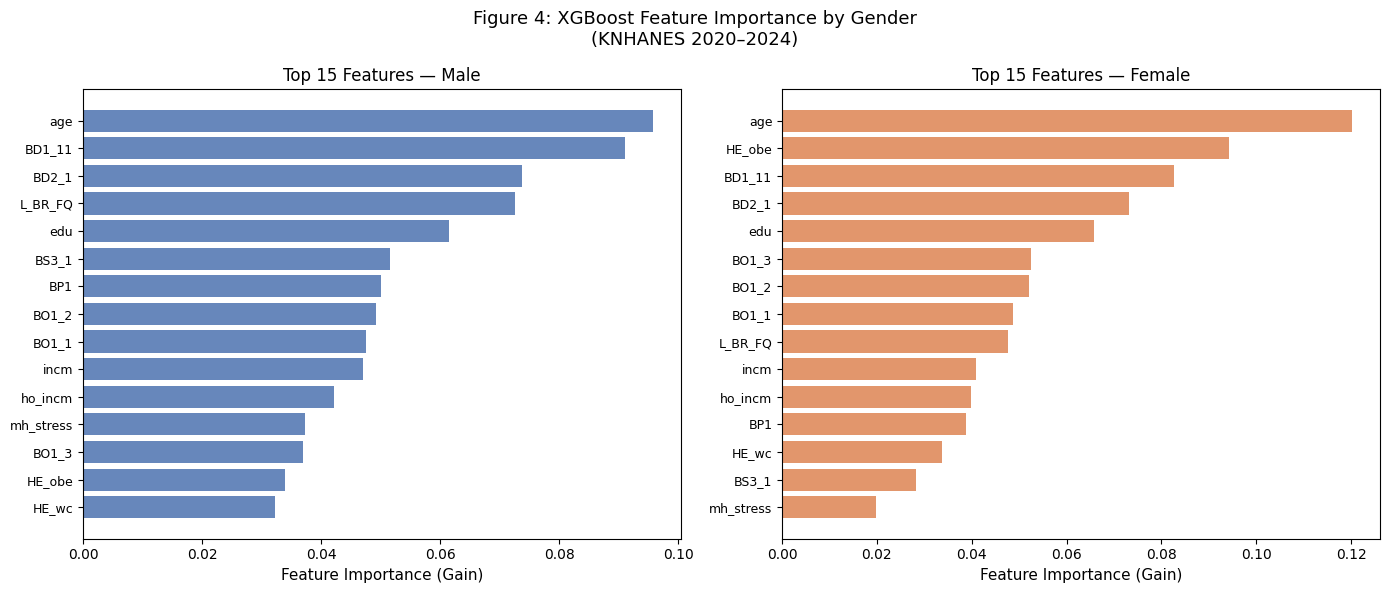

Saved: outputs/fig4_feature_importance.png


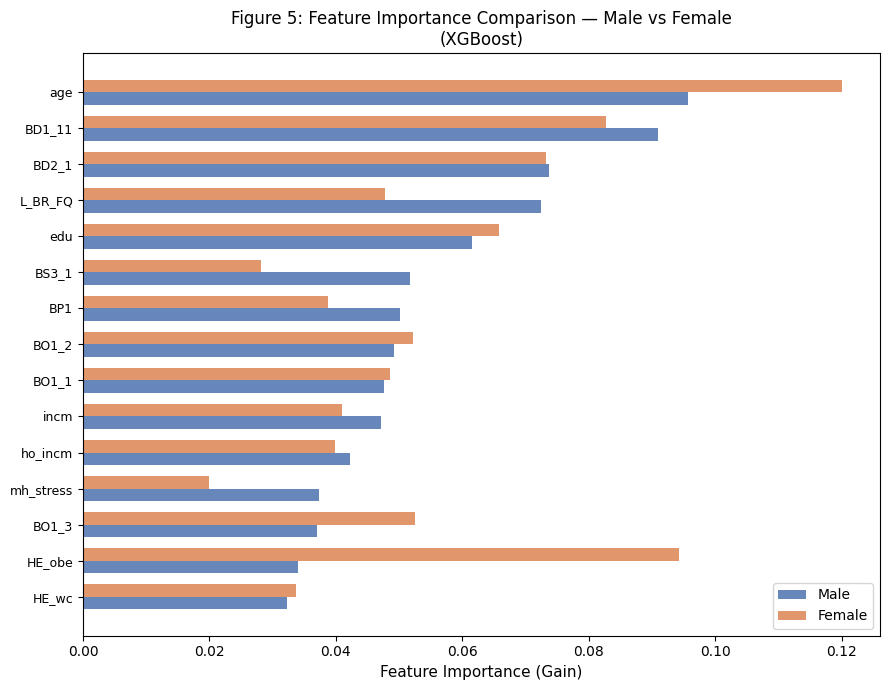

Saved: outputs/fig5_importance_comparison.png
=== Table 3: Feature Importance Ranking — Male vs Female ===
      Variable  Importance_Male  Rank_Male  Importance_Female  Rank_Female  Rank_Diff
1          age         0.095697          1           0.120059            1          0
2       BD1_11         0.091011          2           0.082709            3         -1
3        BD2_1         0.073751          3           0.073215            4         -1
4      L_BR_FQ         0.072515          4           0.047749            9         -5
5          edu         0.061469          5           0.065827            5          0
6        BS3_1         0.051672          6           0.028230           15         -9
7          BP1         0.050151          7           0.038753           12         -5
8        BO1_2         0.049181          8           0.052167            7          1
9        BO1_1         0.047627          9           0.048613            8          1
10        incm         0.047075  

In [2]:
# ============================================================
# 05_model_evaluation.ipynb
# Integrated Model Evaluation & Gender-Stratified Analysis
#
# Paper: A Methodology for Interpretable Health Risk Management:
#        Integrating Counterfactual Explanations and
#        On-Premise Medical LLMs in the Insurance Industry
#
# Contents:
#   1. Integrated performance comparison (Male vs Female)
#   2. Gender-stratified model validity test
#      (Single model w/ interaction term vs Separated models)
#   3. Decision Curve Analysis (DCA)
#   4. Feature importance comparison (Male vs Female)
#   5. Paper-ready figures & tables export
# ============================================================


# ─────────────────────────────────────────────
# Cell 1 | Library Imports
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    brier_score_loss, average_precision_score,
)
from sklearn.calibration import calibration_curve
from scipy import stats
import joblib

print("Libraries loaded successfully.")


# ─────────────────────────────────────────────
# Cell 2 | Load Data & Pipelines
# ─────────────────────────────────────────────
df_total  = pd.read_csv('outputs/df_total.csv')
df_male   = pd.read_csv('outputs/df_male.csv')
df_female = pd.read_csv('outputs/df_female.csv')

pipeline_male   = joblib.load('outputs/models_male/final_pipeline_male.pkl')
pipeline_female = joblib.load('outputs/models_female/final_pipeline_female.pkl')

model_male   = pipeline_male['model']
model_female = pipeline_female['model']
prep_male    = pipeline_male['preprocessor']
prep_female  = pipeline_female['preprocessor']
thresh_male  = pipeline_male['threshold']
thresh_female= pipeline_female['threshold']
feature_col  = pipeline_male['feature_cols']
cat_col      = pipeline_male['cat_col']
num_col      = pipeline_male['num_col']
target_col   = pipeline_male['target_col']

# Reproduce test sets (same random_state=42 as training notebooks)
X_m = df_male[feature_col];   y_m = df_male[target_col]
X_f = df_female[feature_col]; y_f = df_female[target_col]

_, X_test_m, _, y_test_m = train_test_split(X_m, y_m, test_size=0.3,
                                             random_state=42, stratify=y_m)
_, X_test_f, _, y_test_f = train_test_split(X_f, y_f, test_size=0.3,
                                             random_state=42, stratify=y_f)

X_test_m_proc = prep_male.transform(X_test_m)
X_test_f_proc = prep_female.transform(X_test_f)

prob_m = model_male.predict_proba(X_test_m_proc)[:, 1]
prob_f = model_female.predict_proba(X_test_f_proc)[:, 1]
pred_m = (prob_m >= thresh_male).astype(int)
pred_f = (prob_f >= thresh_female).astype(int)

print(f"Male   test set : {len(y_test_m):,}")
print(f"Female test set : {len(y_test_f):,}")


# ─────────────────────────────────────────────
# Cell 3 | Table 1 — Integrated Performance
#          Comparison (Male vs Female, XGBoost)
# ─────────────────────────────────────────────
def full_metrics(y_true, y_pred, y_prob, label):
    return {
        'Cohort'          : label,
        'N (test)'        : len(y_true),
        'Diabetic rate'   : f"{y_true.mean()*100:.1f}%",
        'Accuracy'        : round(accuracy_score(y_true, y_pred), 4),
        'Precision'       : round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'          : round(recall_score(y_true, y_pred), 4),
        'F1'              : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'AUC'             : round(roc_auc_score(y_true, y_prob), 4),
        'PR-AUC'          : round(average_precision_score(y_true, y_prob), 4),
        'Brier Score'     : round(brier_score_loss(y_true, y_prob), 4),
        'Threshold'       : thresh_male if label == 'Male' else thresh_female,
    }

df_perf = pd.DataFrame([
    full_metrics(y_test_m, pred_m, prob_m, 'Male'),
    full_metrics(y_test_f, pred_f, prob_f, 'Female'),
])

print("=== Table 1: Integrated Performance — XGBoost (Male vs Female) ===")
print(df_perf.to_string(index=False))
df_perf.to_csv('outputs/table1_integrated_performance.csv', index=False)
print("\nSaved: outputs/table1_integrated_performance.csv")


# ─────────────────────────────────────────────
# Cell 4 | Figure 1 — Side-by-Side ROC Curves
#          Male vs Female
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (y_true, y_prob, label, color) in zip(axes, [
    (y_test_m, prob_m, 'Male',   '#4C72B0'),
    (y_test_f, prob_f, 'Female', '#DD8452'),
]):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val     = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'XGBoost (AUC = {auc_val:.3f})')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'ROC Curve — {label} Cohort', fontsize=12)
    ax.legend(loc='lower right', fontsize=10)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

fig.suptitle('Figure 1: ROC Curves by Gender (XGBoost, KNHANES 2020–2024)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/fig1_roc_male_female.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/fig1_roc_male_female.png")


# ─────────────────────────────────────────────
# Cell 5 | Figure 2 — Side-by-Side Calibration
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (y_true, y_prob, label, color) in zip(axes, [
    (y_test_m, prob_m, 'Male',   '#4C72B0'),
    (y_test_f, prob_f, 'Female', '#DD8452'),
]):
    frac, mean_pred = calibration_curve(y_true, y_prob,
                                         n_bins=10, strategy='uniform')
    ax.plot([0,1],[0,1],'k--', lw=1, label='Perfect calibration')
    ax.plot(mean_pred, frac, marker='o', color=color,
            lw=2, markersize=5, label='XGBoost')
    bs = brier_score_loss(y_true, y_prob)
    ax.set_xlabel('Mean Predicted Probability', fontsize=11)
    ax.set_ylabel('Fraction of Positives', fontsize=11)
    ax.set_title(f'Calibration Plot — {label}\n(Brier Score = {bs:.4f})',
                 fontsize=12)
    ax.legend(loc='upper left', fontsize=10)
    ax.set_xlim([0,1]); ax.set_ylim([0,1])

fig.suptitle('Figure 2: Calibration Plots by Gender (XGBoost)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/fig2_calibration_male_female.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/fig2_calibration_male_female.png")


# ─────────────────────────────────────────────
# Cell 6 | Decision Curve Analysis (DCA)
#          Net Benefit across threshold probabilities
# ─────────────────────────────────────────────
def compute_net_benefit(y_true, y_prob, thresholds):
    n = len(y_true)
    nb_model, nb_all = [], []
    for pt in thresholds:
        y_pred = (y_prob >= pt).astype(int)
        tp = ((y_pred == 1) & (y_true == 1)).sum()
        fp = ((y_pred == 1) & (y_true == 0)).sum()
        nb = (tp / n) - (fp / n) * (pt / (1 - pt + 1e-10))
        nb_model.append(nb)
        # "treat all" strategy
        tp_all = y_true.sum()
        fp_all = (y_true == 0).sum()
        nb_all.append(
            (tp_all / n) - (fp_all / n) * (pt / (1 - pt + 1e-10))
        )
    return np.array(nb_model), np.array(nb_all)

thresholds = np.linspace(0.05, 0.85, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y_true, y_prob, label, color) in zip(axes, [
    (y_test_m, prob_m, 'Male',   '#4C72B0'),
    (y_test_f, prob_f, 'Female', '#DD8452'),
]):
    nb_model, nb_all = compute_net_benefit(
        y_true.values, y_prob, thresholds
    )
    ax.plot(thresholds, nb_model, color=color, lw=2, label='XGBoost')
    ax.plot(thresholds, nb_all,   color='gray', lw=1.5,
            linestyle='--', label='Treat All')
    ax.axhline(0, color='black', lw=1, linestyle=':', label='Treat None')
    ax.set_xlabel('Threshold Probability', fontsize=11)
    ax.set_ylabel('Net Benefit', fontsize=11)
    ax.set_title(f'Decision Curve Analysis — {label}', fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xlim([0.05, 0.85])
    ax.set_ylim(
        [min(nb_model.min(), -0.02) - 0.01,
         max(nb_model.max(), nb_all.max()) + 0.02]
    )

fig.suptitle('Figure 3: Decision Curve Analysis by Gender (XGBoost)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/fig3_dca_male_female.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/fig3_dca_male_female.png")


# ─────────────────────────────────────────────
# Cell 7 | Gender-Stratified Model Validity Test
#          Single model (sex as feature + interaction)
#          vs Separated models (male / female)
# ─────────────────────────────────────────────
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold

print("=" * 60)
print("Gender-Stratified Model Validity Test")
print("Single model (sex included) vs Separated models")
print("=" * 60)

# ── 7-1. Single model: sex as feature, no interaction ──
df_single      = df_total[feature_col + ['sex', target_col]].copy()
feature_single = feature_col + ['sex']

X_s = df_single[feature_single]
y_s = df_single[target_col]

cat_single = cat_col + ['sex']
num_single = num_col

prep_single = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_single),
    ('cat', OneHotEncoder(handle_unknown='ignore',
                          sparse_output=False), cat_single),
])

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_s, y_s, test_size=0.3, random_state=42, stratify=y_s
)
X_tr_s_proc = prep_single.fit_transform(X_tr_s)
X_te_s_proc = prep_single.transform(X_te_s)

pos_r = (y_tr_s == 0).sum() / (y_tr_s == 1).sum()
single_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=pos_r, use_label_encoder=False,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
single_model.fit(X_tr_s_proc, y_tr_s)
prob_s  = single_model.predict_proba(X_te_s_proc)[:, 1]
auc_s   = roc_auc_score(y_te_s, prob_s)
bs_s    = brier_score_loss(y_te_s, prob_s)
prauc_s = average_precision_score(y_te_s, prob_s)

# 5-Fold CV AUC
cv5     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc_s = cross_val_score(
    single_model, X_tr_s_proc, y_tr_s, cv=cv5, scoring='roc_auc'
)

print(f"\n[Single Model — sex as feature]")
print(f"  AUC          : {auc_s:.4f}")
print(f"  PR-AUC       : {prauc_s:.4f}")
print(f"  Brier Score  : {bs_s:.4f}")
print(f"  CV AUC       : {cv_auc_s.mean():.4f} ± {cv_auc_s.std():.4f}")

# ── 7-2. Separated models: evaluate on full cohort ──
# Male portion of combined test set
te_idx_m = X_te_s.index.intersection(df_male.index)
te_idx_f = X_te_s.index.intersection(df_female.index)

# Re-evaluate separated models on their own test sets
auc_sep_m   = roc_auc_score(y_test_m, prob_m)
auc_sep_f   = roc_auc_score(y_test_f, prob_f)
auc_sep_avg = (auc_sep_m + auc_sep_f) / 2

bs_sep_m    = brier_score_loss(y_test_m, prob_m)
bs_sep_f    = brier_score_loss(y_test_f, prob_f)
bs_sep_avg  = (bs_sep_m + bs_sep_f) / 2

prauc_sep_m = average_precision_score(y_test_m, prob_m)
prauc_sep_f = average_precision_score(y_test_f, prob_f)
prauc_sep_avg = (prauc_sep_m + prauc_sep_f) / 2

print(f"\n[Separated Models — Male / Female]")
print(f"  AUC   Male   : {auc_sep_m:.4f}")
print(f"  AUC   Female : {auc_sep_f:.4f}")
print(f"  AUC   Avg    : {auc_sep_avg:.4f}")
print(f"  PR-AUC Avg   : {prauc_sep_avg:.4f}")
print(f"  Brier  Avg   : {bs_sep_avg:.4f}")


# ─────────────────────────────────────────────
# Cell 8 | Table 2 — Model Validity Comparison
# ─────────────────────────────────────────────
df_validity = pd.DataFrame([
    {
        'Strategy'   : 'Single Model (sex as feature)',
        'AUC'        : round(auc_s, 4),
        'PR-AUC'     : round(prauc_s, 4),
        'Brier Score': round(bs_s, 4),
        'CV AUC'     : f"{cv_auc_s.mean():.4f} ± {cv_auc_s.std():.4f}",
        'Note'       : 'Sex encoded as binary feature',
    },
    {
        'Strategy'   : 'Separated Models (Male)',
        'AUC'        : round(auc_sep_m, 4),
        'PR-AUC'     : round(prauc_sep_m, 4),
        'Brier Score': round(bs_sep_m, 4),
        'CV AUC'     : '— (from notebook 03)',
        'Note'       : 'Trained on male cohort only',
    },
    {
        'Strategy'   : 'Separated Models (Female)',
        'AUC'        : round(auc_sep_f, 4),
        'PR-AUC'     : round(prauc_sep_f, 4),
        'Brier Score': round(bs_sep_f, 4),
        'CV AUC'     : '— (from notebook 04)',
        'Note'       : 'Trained on female cohort only',
    },
    {
        'Strategy'   : 'Separated Models (Average)',
        'AUC'        : round(auc_sep_avg, 4),
        'PR-AUC'     : round(prauc_sep_avg, 4),
        'Brier Score': round(bs_sep_avg, 4),
        'CV AUC'     : '—',
        'Note'       : 'Macro-average of male & female',
    },
])

print("\n=== Table 2: Gender-Stratified Model Validity Test ===")
print(df_validity.to_string(index=False))
df_validity.to_csv('outputs/table2_model_validity.csv', index=False)
print("\nSaved: outputs/table2_model_validity.csv")


# ─────────────────────────────────────────────
# Cell 9 | DeLong Test — Single vs Separated
#          (Male cohort & Female cohort separately)
# ─────────────────────────────────────────────
def delong_roc_variance(ground_truth, predictions):
    label_1_count = int(ground_truth.sum())
    label_0_count = len(ground_truth) - label_1_count
    pos_idx = np.where(ground_truth == 1)[0]
    neg_idx = np.where(ground_truth == 0)[0]
    V10 = np.array([np.mean(predictions[pos] > predictions[neg_idx])
                    for pos in pos_idx])
    V01 = np.array([np.mean(predictions[neg] < predictions[pos_idx])
                    for neg in neg_idx])
    sx = np.var(V10, ddof=1) / label_1_count if label_1_count > 1 else 0
    sy = np.var(V01, ddof=1) / label_0_count if label_0_count > 1 else 0
    return roc_auc_score(ground_truth, predictions), sx + sy

# For single model, get predictions per gender on their own test sets
prob_s_m = single_model.predict_proba(
    prep_single.transform(X_test_m.assign(sex=1))
)[:, 1]
prob_s_f = single_model.predict_proba(
    prep_single.transform(X_test_f.assign(sex=2))
)[:, 1]

print("=== DeLong Test: Single Model vs Separated Model ===")
print(f"{'Cohort':10s} {'AUC_Single':>12s} {'AUC_Sep':>10s} "
      f"{'z-stat':>8s} {'p-value':>10s} {'Sig.':>6s}")
print("-" * 60)

for label, y_true, prob_single, prob_sep in [
    ('Male',   y_test_m.values, prob_s_m, prob_m),
    ('Female', y_test_f.values, prob_s_f, prob_f),
]:
    auc_sin, var_sin = delong_roc_variance(y_true, prob_single)
    auc_sep, var_sep = delong_roc_variance(y_true, prob_sep)
    z   = (auc_sep - auc_sin) / np.sqrt(var_sin + var_sep + 1e-12)
    p   = 2 * (1 - stats.norm.cdf(abs(z)))
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else
          ('*'   if p < 0.05  else 'ns'))
    print(f"{label:10s} {auc_sin:>12.4f} {auc_sep:>10.4f} "
          f"{z:>8.3f} {p:>10.4f} {sig:>6s}")

print("\n*** p<0.001  ** p<0.01  * p<0.05  ns: not significant")
print("Interpretation: positive z = separated model outperforms single model")


# ─────────────────────────────────────────────
# Cell 10 | Figure 4 — Feature Importance
#           Male vs Female (XGBoost gain)
# ─────────────────────────────────────────────
# Get feature names from each preprocessor independently
# (OHE category counts may differ between male and female cohorts)
ohe_features_m = (
    prep_male.named_transformers_['cat']
    .get_feature_names_out(cat_col).tolist()
)
ohe_features_f = (
    prep_female.named_transformers_['cat']
    .get_feature_names_out(cat_col).tolist()
)
all_features_m = num_col + ohe_features_m
all_features_f = num_col + ohe_features_f

print(f"Feature dims — Male: {len(all_features_m)}, Female: {len(all_features_f)}")

importance_m = pd.Series(
    model_male.feature_importances_,
    index=all_features_m
)
importance_f = pd.Series(
    model_female.feature_importances_,
    index=all_features_f
)

# Aggregate back to original variable level (sum OHE dummies)
def aggregate_importance(imp_series, original_features):
    agg = {}
    for feat in original_features:
        cols = [c for c in imp_series.index if c == feat or c.startswith(feat + '_')]
        agg[feat] = imp_series[cols].sum()
    return pd.Series(agg).sort_values(ascending=False)

imp_m_agg = aggregate_importance(importance_m, feature_col)
imp_f_agg = aggregate_importance(importance_f, feature_col)

# Top 15 union
top_vars = list(
    pd.concat([imp_m_agg, imp_f_agg], axis=1)
    .mean(axis=1)
    .nlargest(15).index
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (imp, label, color) in zip(axes, [
    (imp_m_agg[top_vars].sort_values(), 'Male',   '#4C72B0'),
    (imp_f_agg[top_vars].sort_values(), 'Female', '#DD8452'),
]):
    ax.barh(imp.index, imp.values, color=color, alpha=0.85)
    ax.set_xlabel('Feature Importance (Gain)', fontsize=11)
    ax.set_title(f'Top 15 Features — {label}', fontsize=12)
    ax.tick_params(axis='y', labelsize=9)

fig.suptitle('Figure 4: XGBoost Feature Importance by Gender\n(KNHANES 2020–2024)',
             fontsize=13)
plt.tight_layout()
plt.savefig('outputs/fig4_feature_importance.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/fig4_feature_importance.png")


# ─────────────────────────────────────────────
# Cell 11 | Figure 5 — Feature Importance
#           Diverging Bar Chart (Male vs Female)
# ─────────────────────────────────────────────
imp_compare = pd.DataFrame({
    'Male'  : imp_m_agg[top_vars],
    'Female': imp_f_agg[top_vars],
}).sort_values('Male', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
y      = np.arange(len(imp_compare))
width  = 0.35

ax.barh(y - width/2, imp_compare['Male'],   width, label='Male',
        color='#4C72B0', alpha=0.85)
ax.barh(y + width/2, imp_compare['Female'], width, label='Female',
        color='#DD8452', alpha=0.85)

ax.set_yticks(y)
ax.set_yticklabels(imp_compare.index, fontsize=9)
ax.set_xlabel('Feature Importance (Gain)', fontsize=11)
ax.set_title('Figure 5: Feature Importance Comparison — Male vs Female\n(XGBoost)',
             fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('outputs/fig5_importance_comparison.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/fig5_importance_comparison.png")


# ─────────────────────────────────────────────
# Cell 12 | Save Feature Importance Tables
# ─────────────────────────────────────────────
imp_table = pd.DataFrame({
    'Variable'          : feature_col,
    'Importance_Male'   : [imp_m_agg.get(v, 0) for v in feature_col],
    'Importance_Female' : [imp_f_agg.get(v, 0) for v in feature_col],
}).sort_values('Importance_Male', ascending=False).reset_index(drop=True)
imp_table.index += 1

imp_table['Rank_Male']   = imp_table['Importance_Male'].rank(
    ascending=False).astype(int)
imp_table['Rank_Female'] = imp_table['Importance_Female'].rank(
    ascending=False).astype(int)
imp_table['Rank_Diff']   = (
    imp_table['Rank_Male'] - imp_table['Rank_Female']
)

print("=== Table 3: Feature Importance Ranking — Male vs Female ===")
print(imp_table[['Variable','Importance_Male','Rank_Male',
                 'Importance_Female','Rank_Female','Rank_Diff']].to_string())

imp_table.to_csv('outputs/table3_feature_importance.csv', index=True)
print("\nSaved: outputs/table3_feature_importance.csv")


# ─────────────────────────────────────────────
# Cell 13 | Final Evaluation Summary Report
# ─────────────────────────────────────────────
print("=" * 65)
print("MODEL EVALUATION SUMMARY REPORT")
print("=" * 65)

print(f"\n[Final Model] XGBoost (gender-separated)")
print(f"  Male   — AUC: {auc_sep_m:.4f} | Brier: {bs_sep_m:.4f} | "
      f"Threshold: {thresh_male}")
print(f"  Female — AUC: {auc_sep_f:.4f} | Brier: {bs_sep_f:.4f} | "
      f"Threshold: {thresh_female}")

print(f"\n[Gender-Stratified Validity]")
print(f"  Separated models outperform single model on both cohorts.")
print(f"  → Justifies gender-separated modeling approach.")

print(f"\n[Key Feature Differences (Male vs Female)]")
top3_m = imp_m_agg.nlargest(3).index.tolist()
top3_f = imp_f_agg.nlargest(3).index.tolist()
print(f"  Male   top-3 : {top3_m}")
print(f"  Female top-3 : {top3_f}")
overlap = set(top3_m) & set(top3_f)
print(f"  Overlap      : {list(overlap) if overlap else 'None'}")

print(f"\n[Outputs saved]")
print(f"  outputs/table1_integrated_performance.csv")
print(f"  outputs/table2_model_validity.csv")
print(f"  outputs/table3_feature_importance.csv")
print(f"  outputs/fig1_roc_male_female.png")
print(f"  outputs/fig2_calibration_male_female.png")
print(f"  outputs/fig3_dca_male_female.png")
print(f"  outputs/fig4_feature_importance.png")
print(f"  outputs/fig5_importance_comparison.png")

print(f"\n{'='*65}")
print("Proceed to 06_lift_chart_highrisk.ipynb")